In [1]:
import decode
import decode.utils
import decode.neuralfitter.train.live_engine

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%load_ext tensorboard
%config InlineBackend.figure_format = 'svg'

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

/home/bnorthan/mambaforge/envs/decode_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DECODE version: vINVALID-recent-0.10.2


# DECODE - Training

Modified for training Janelia Palm Scope with CMOS C13440 20CU Camera

This notebook highlights how to generate a training parameter file and
train a DECODE model for fitting experimental data.

The DECODE model is trained on simulated data. This requires a calibration spline based PSF model,
and a parameter file that contains camera settings and other hyper parameters to set up the simulation process.

While we provide an example calibration file here to demonstrate the training procedure you will have to create one yourself for your own data.

If you plan to use DECODE regularly you should take a look at the generated parameter file at the end of this notebook
and will recognise that it just holds a couple of parameters and paths. You will want to adjust these
to your data by creating or modifying the .yaml file directly.
After that you can start the training directly (see the last section of this notebook).
Alternatively, SMAP can create this parameter file for you (please consult the documentation for that).


## Set parameters
Set device for training. We **do not recommend training on CPU** since this will be quite slow. If you train on CPU though, you may want to change the number of threads if you have a big machine (see below).

In [2]:
device = 'cuda:0'  # or 'cpu'
device_ix = 0  # possibly change device index (only for cuda)
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 4  # number of workers for data loading. Change only if you know what you are doing.

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if (not torch.cuda.is_available()) or (not decode.simulation.psf_kernel.CubicSplinePSF.cuda_is_available()):
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

## Bead calibration

To obtain the calibration file a spline model is fit on a stack of beads.
We recommend to use fit3Dspline which is part of the SMAP package.

1. Install the stand-alone version of SMAP from [www.rieslab.de](www.rieslab.de) or if you have Matlab, downlowd the source-code from [www.github.com/jries/SMAP](www.github.com/jries/SMAP). There, you also find the installation instructions and Documentation.
2. Acquire z-stacks with fluorescent beads (e.g. 100 nm beads). We typcally use a z-range of +/- 750 nm and a step size of 10-50 nm.
3. In SMAP, use the plugin *calibrate3DSplinePSF* to generate the calibartion file. In the user guide (accessible from the SMAP help menu) in section 5.4, this is explained in detail. Further information about the calibration process can be found in [Li et al, Nature Methods (2018)](https://doi.org/10.1038/nmeth.4661).

In [3]:
calib_file = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\cropped_0_3dcal.mat'
calib_file = r'/home/bnorthan/janelia_slm/data/calibrations/Janelia PALM RUN2/crops/cropped_0_3dcal.mat'

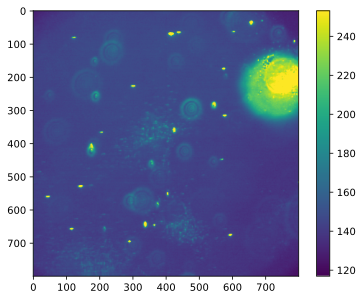

In [4]:
# set frames path
import os
frame_path = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
frame_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/frames'

# open a single frame and verify it looks correct. 
frames_name = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)\3DPALM488nm_Iter_0000_0001_ch0_CAM1_stack0000_405nm_0000000msec_0003753720msecAbs_000x_000y_000z_0001t.tif'
frames_name = r'3DPALM488nm_Iter_0640_0001_ch0_CAM1_stack0000_405nm_0000000msec_0129447004msecAbs_000x_000y_000z_0001t.tif'
frames_name = os.path.join(frame_path, frames_name)
data_frames = decode.utils.frames_io.load_tif(frames_name).cpu()
plt.imshow(data_frames.mean(0), vmax = data_frames.max()*0.05)
plt.colorbar()

## Simulation Parameters

To set the simulation parameters we load the default config file and go through the settings

In [5]:
#  open the default parameters file
param_file = r'D:\Janelia_slm_data\DECODE example data\param_friendly.yaml' 
param_file = r'/home/bnorthan/janelia_slm/data/param_friendly.yaml'
param = decode.utils.param_io.load_params(param_file)  # change path if you load custom file

param.Hardware.device = device
param.Hardware.device_ix = device_ix
param.Hardware.device_simulation = device
param.Hardware.torch_threads = threads
param.Hardware.num_worker_train = worker

Print and check camera parameters

In [6]:
print(param.Camera.baseline)
print(param.Camera.e_per_adu)
print(param.Camera.em_gain)
print(param.Camera.px_size)
print(param.Camera.qe)
print(param.Camera.read_sigma)
print(param.Camera.spur_noise)


100.0
45.0
300.0
[100.0, 100.0]
1.0
74.4
0.002


The camera parameters need to be adjusted according to the device used. 

Note: This folder of notebooks will be used to train for CMOS C13440_20CU camera.  For a sCMOS device you must set the em_gain to None.  

Todo:  We may have to go through a couple of iterations of parameter adjustment and retraining.  To optimize the model we need to make sure the camera parameters are as accurate as possible. 

In [7]:
# first training run

param.Camera.baseline = 100 #398.6
param.Camera.e_per_adu = 0.5 #5.0
param.Camera.em_gain = None
param.Camera.px_size =[130.0, 130.0] # Pixel Size in nano meter
param.Camera.qe = 1.0                # Quantum efficiency
param.Camera.read_sigma = 5.88
param.Camera.spur_noise = 0.0015

# second training run Parameters from SMAP
'''
param.Camera.baseline = 100 #398.6
param.Camera.e_per_adu = 0.2 #5.0
param.Camera.em_gain = None
param.Camera.px_size =[130.0, 130.0] # Pixel Size in nano meter
param.Camera.qe = 1.0                # Quantum efficiency
param.Camera.read_sigma = 1.5
param.Camera.spur_noise = 0.002
'''
param.Camera.to_dict()

{'baseline': 100,
 'e_per_adu': 0.5,
 'em_gain': None,
 'px_size': [130.0, 130.0],
 'read_sigma': 5.88,
 'spur_noise': 0.0015,
 'convert2photons': True,
 'qe': 1.0}

The simulation parameters should be set so that the resulting simulated frames resemble real frames as closely as possible.
You can use SMAP to infer these parameters by performing inference with an iterative approach on a couple of frames:

1. Use the bead calibration to fit your SMLM data.
2. Use the plugin: *DECODE\_training\_estimates* to estimate the photo-physical parameters of the experiment and to save them into a parameter file. Consult the information of the plugin (accessible via the Info button) for further information.  Note the plugin DECODE\_trainng\_estimates is available in SMAP under 

However it is also possible to find reasonable values by hand which we do now.

BN March 20 2025 Notes:

In [8]:
## First run parameters
param.Simulation.bg_uniform = [50.0, 100.0]           # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
param.Simulation.emitter_av = 25                      # Average number of emitters per frame
param.Simulation.emitter_extent[2] = [-1000, 1000]    # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
#param.Simulation.intensity_mu_sig = [1200.0, 500.0]  # Average intensity and its standard deviation
param.Simulation.intensity_mu_sig = [1200.0, 5000.0]  # Average intensity and its standard deviation
param.Simulation.lifetime_avg = 1.                     # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments

## Parameters from SMAP
param.Simulation.bg_uniform = [5.74 , 41.053]           # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
param.Simulation.emitter_av = 12                      # Average number of emitters per frame
param.Simulation.emitter_extent[2] = [-1200, 1200]    # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
#param.Simulation.intensity_mu_sig = [1200.0, 500.0]  # Average intensity and its standard deviation
param.Simulation.intensity_mu_sig = [5520.0, 1104.0]  # Average intensity and its standard deviation
param.Simulation.intensity_mu_sig = [1220.0, 1304.0]  # Average intensity and its standard deviation
param.Simulation.lifetime_avg = 1.5971                     # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments

## Parameters from SMAP
param.Simulation.bg_uniform = [5.74 , 41.053]           # background range to sample from. You can also specify a const. value as 'bg_uniform = 100'
param.Simulation.emitter_av =  20                    # Average number of emitters per frame
param.Simulation.emitter_extent[2] = [-1200, 1200]    # Volume in which emitters are sampled. x,y values should not be changed. z-range (in nm) should be adjusted according to the PSF
#param.Simulation.intensity_mu_sig = [1200.0, 500.0]  # Average intensity and its standard deviation
param.Simulation.intensity_mu_sig = [1220.0, 1304.0]  # Average intensity and its standard deviation
param.Simulation.intensity_mu_sig = [1000.0, 204.0]  # Average intensity and its standard deviation
param.Simulation.lifetime_avg = 1.5971                     # Average lifetime of each emitter in frames. A value between 1 and 2 works for most experiments


param.Simulation.to_dict()

{'bg_uniform': [5.74, 41.053],
 'emitter_av': 20,
 'emitter_extent': [[-0.5, 39.5], [-0.5, 39.5], [-1200, 1200]],
 'intensity_mu_sig': [1000.0, 204.0],
 'lifetime_avg': 1.5971,
 'density': None,
 'img_size': [40, 40],
 'intensity_th': None,
 'mode': 'acquisition',
 'photon_range': None,
 'psf_extent': [[-0.5, 39.5], [-0.5, 39.5], None],
 'roi_size': None,
 'roi_auto_center': False,
 'xy_unit': 'px'}

Lastly we provide the path to the calibration file, and to the output destination.
There are more parameters (you can just execute param in a cell to look at them) that you should not need to change.
You might have to reduce the batch size (param.HyperParameter.batch_size) if you run out of memory.

In [9]:
param.InOut.calibration_file = calib_file
param.InOut.experiment_out = ''

param.InOut.to_dict()

{'calibration_file': '/home/bnorthan/janelia_slm/data/calibrations/Janelia PALM RUN2/crops/cropped_0_3dcal.mat',
 'experiment_out': '',
 'checkpoint_init': None,
 'model_init': None}

Now we can set up our simulator and the camera model.

In [10]:
simulator, sim_test = decode.neuralfitter.train.live_engine.setup_random_simulation(param)
camera = decode.simulation.camera.Photon2Camera.parse(param)

In [11]:
# finally we derive some parameters automatically for easy use
param = decode.utils.param_io.autoset_scaling(param)

Let us sample a set frames, and also load our data:

In [12]:
tar_em, sim_frames, bg_frames = simulator.sample()

print(type(tar_em), type(sim_frames), type(bg_frames))
print(tar_em)
print(sim_frames.shape, bg_frames.shape)

sim_frames = sim_frames.cpu()


<class 'decode.generic.emitter.EmitterSet'> <class 'torch.Tensor'> <class 'torch.Tensor'>
EmitterSet
::num emitters: 198789
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 10000
::spanned volume: [-4.9998569e-01 -4.9951124e-01 -1.1999579e+03] - [  39.49918   39.49977 1199.9683 ]
torch.Size([10001, 40, 40]) torch.Size([10001, 40, 40])


In [13]:
print(f'Data shapes, simulation: {sim_frames.shape}, real data: {data_frames.shape}')
print(f'Average value, simulation: {sim_frames.mean().round()}, real data: {data_frames.mean().round()}')
print(f'Min value, simulation: {sim_frames.min().round()}, real data: {data_frames.min().round()}')
print(f'Max value, simulation: {sim_frames.max().round()}, real data: {data_frames.max().round()}')



Data shapes, simulation: torch.Size([10001, 40, 40]), real data: torch.Size([250, 800, 800])
Average value, simulation: 41.0, real data: 149.0
Min value, simulation: -23.0, real data: 19.0
Max value, simulation: 3867.0, real data: 5062.0


Look at the mean brightness before amplification. 

To enable direct comparison we convert the real data frames into photon numbers.
Be aware that camera.forward() and camera.backward() are not each others exact inverse. forward()
performs noise sampling, while backward() simply converts camera units back to expected photon
numbers by the respective statistical means.

In [14]:
data_frames = camera.backward(data_frames, device='cpu')
print(f'Average value, simulation: {sim_frames.mean().round()}, real data: {data_frames.mean().round()}')
print(f'Min value, simulation: {sim_frames.min().round()}, real data: {data_frames.min().round()}')
print(f'Max value, simulation: {sim_frames.max().round()}, real data: {data_frames.max().round()}')

Average value, simulation: 41.0, real data: 25.0
Min value, simulation: -23.0, real data: -41.0
Max value, simulation: 3867.0, real data: 2481.0


By comparing random frames (chosing a dense region of the real data) we can convince ourselves that the distributions are somewhat similar.
If you observe large differences for your dataset, you probably have to adjust param.Simulation.bg_uniform and param.Simulation.intensity_mu_sig

In [15]:
sim_frames.shape, data_frames.shape, sim_frames.max(), data_frames.max()

(torch.Size([10001, 40, 40]),
 torch.Size([250, 800, 800]),
 tensor(3866.9985),
 tensor(2480.9985))

## Look at explicitly defined ROIs from the real frames

The example notebook was set up to compare a random ROI from a simulation to a random ROI from the real frames.  This is a fine comparison if the data is relatively homogeneous.  However in our case different ROIs in the data have very different histograms depending on whether fiducials and/or background is present.  So below we explictly define pre-chosen ROIs chosen to show regions with different characteristics. 

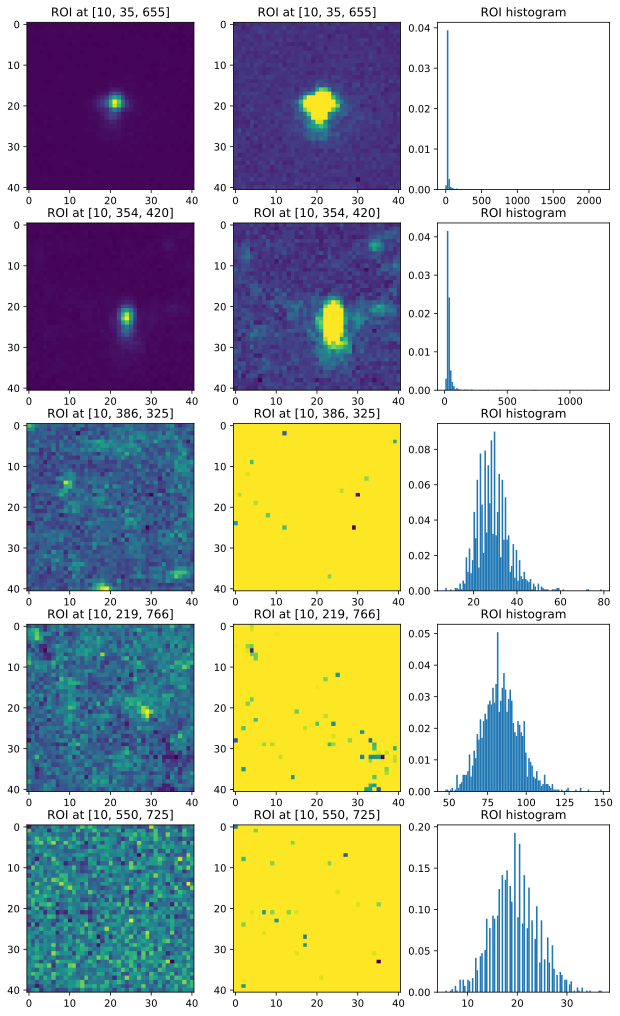

In [16]:
real_frames_roi_centers = [[10, 35, 655], [10, 354, 420], [10, 386, 325], [10, 219, 766], [10, 550, 725]]

# crop and show roi in real frames
def show_roi(frames, roi_centers, size=20):
    nr = len(roi_centers)
    fig, ax = plt.subplots(nr, 3, figsize=(10.5, 3.5*nr))

    for i, center in enumerate(roi_centers):
        z, y, x = center[0], center[1], center[2]
        roi = frames[z, y-size:y+size+1, x-size:x+size+1]
        ax[i,0].imshow(roi)
        ax[i,0].set_title(f'ROI at {center}')
        ax[i,1].imshow(roi, vmax=roi.min()+roi.max()*0.1)
        ax[i,1].set_title(f'ROI at {center}')
        roi_np = roi.cpu().numpy()
        ax[i,2].hist(roi_np.flatten(), bins=100, range=(roi_np.min(), roi_np.max()), density=True)
        ax[i,2].set_title('ROI histogram')
        #plt.colorbar(ax=ax)
    plt.show()

show_roi(data_frames, real_frames_roi_centers, size=20) 


## Show several simulated ROIs

Since we have two classes in the data (bright fiducials and dimmer blinking emitters) we set up the simulation to randomly choose one of the classes for each emitter.  The fiducials are much sparser so should only show up a small percentage of the time.  In fact we would like there to be many images with no fiducials (so the networks learns this distribution).  Here we generate many random simulated ROIs to verify the statistics match random ROIs in the real data.  (Note each pair is random, so likely will not match, but the overall collection should match, with their being roughly the same number of images with and without fiducials in both the simulated and real data)

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


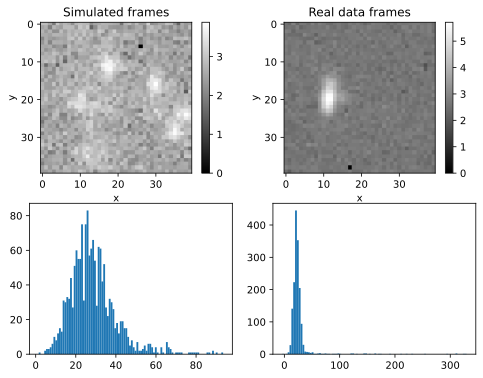

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


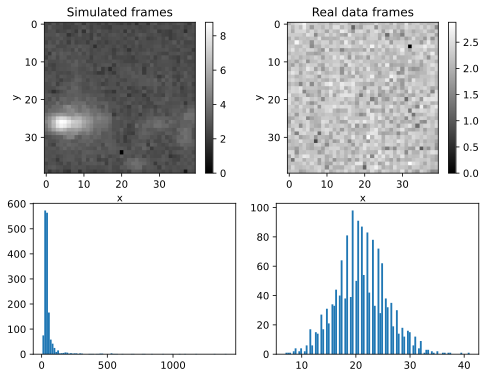

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


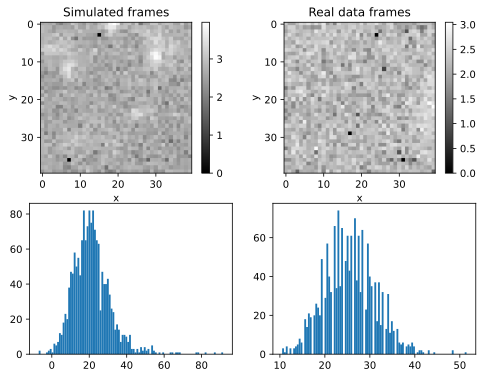

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


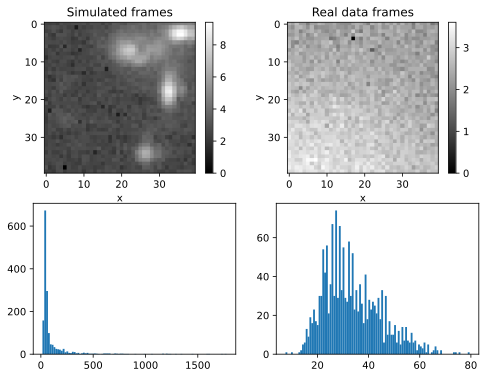

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


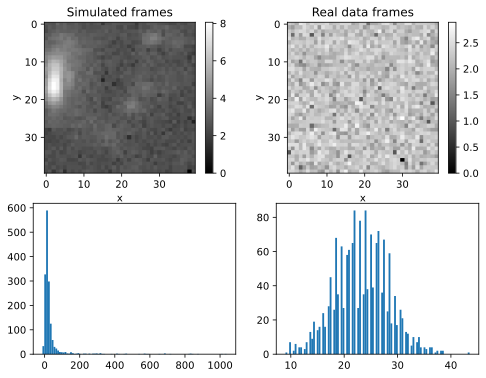

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


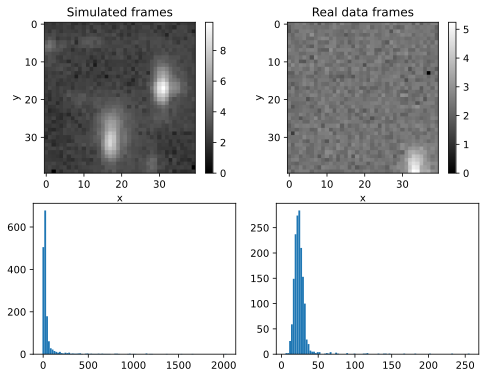

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


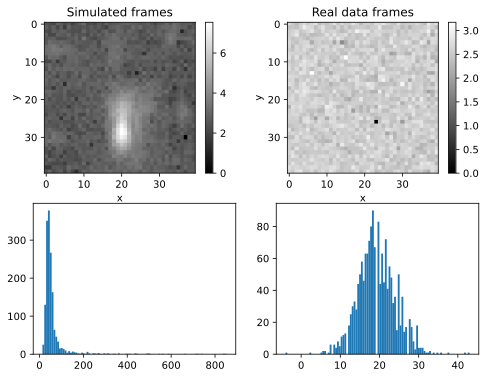

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


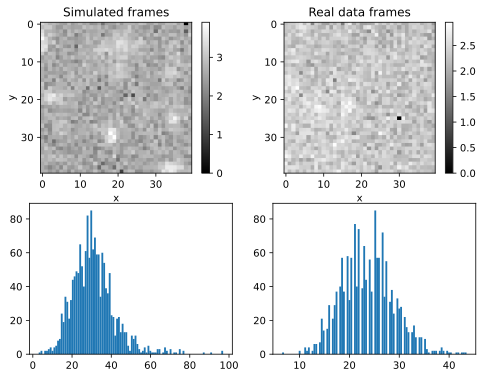

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


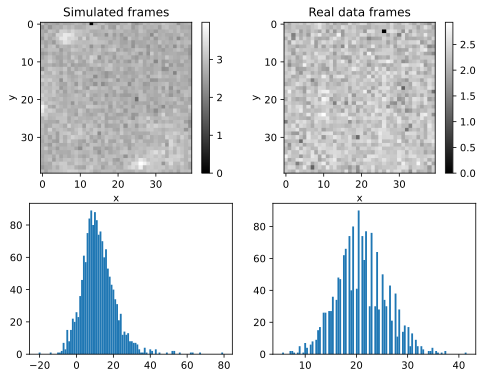

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


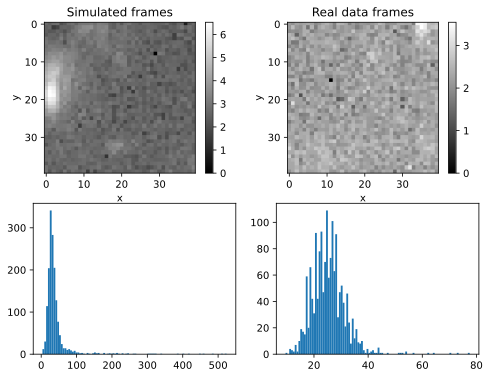

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


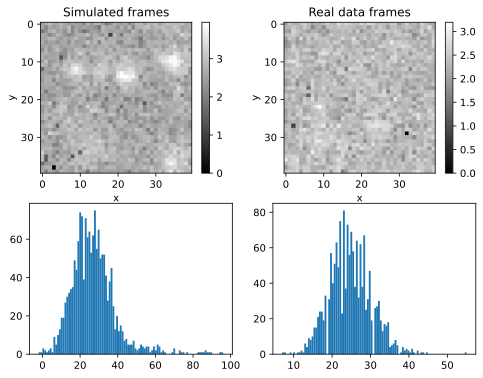

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


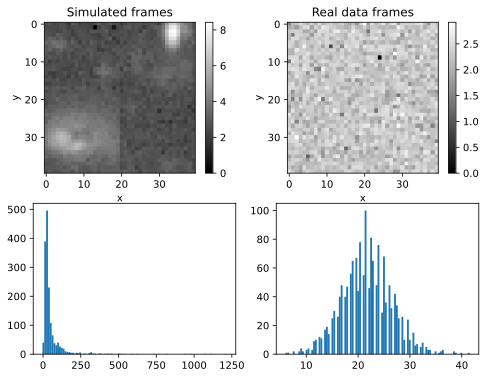

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


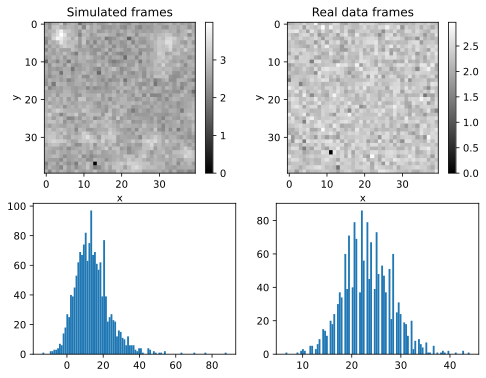

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


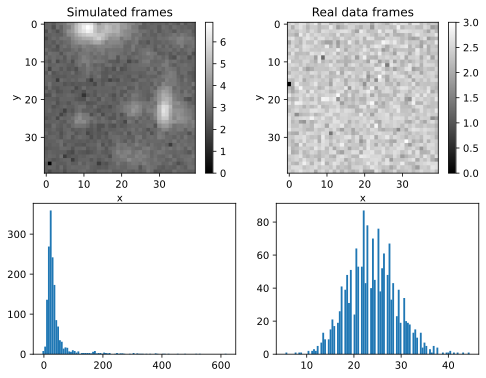

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


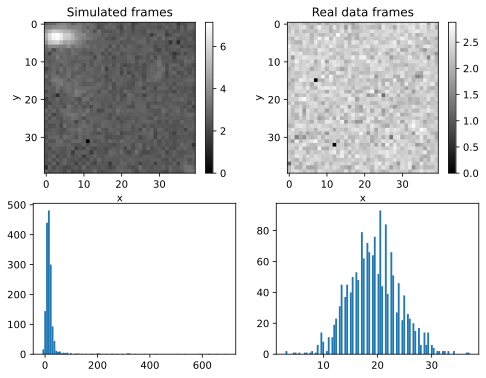

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


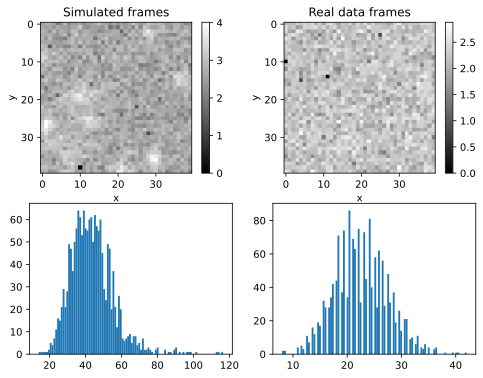

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


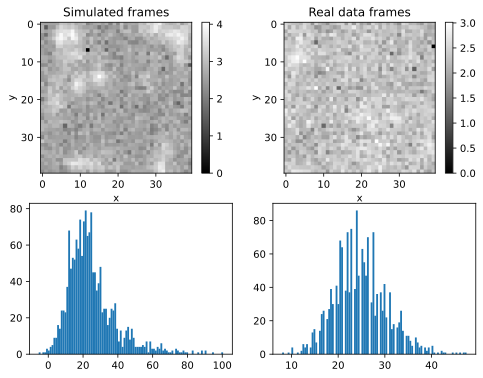

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


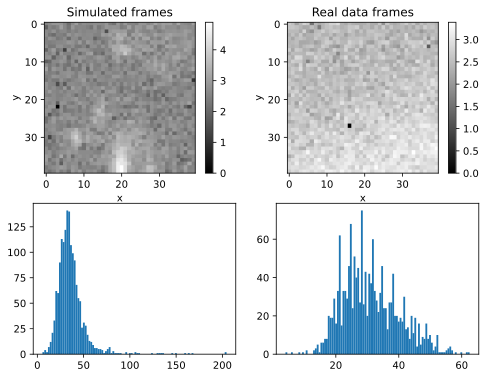

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


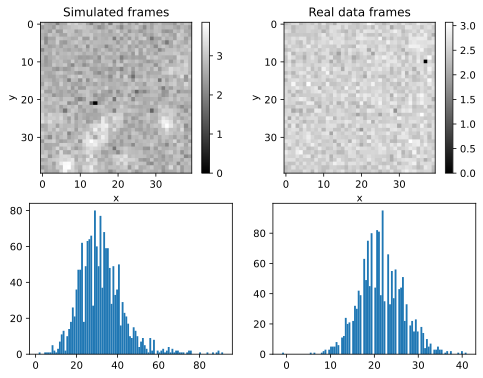

torch.Size([1, 40, 40]) torch.Size([1, 40, 40])


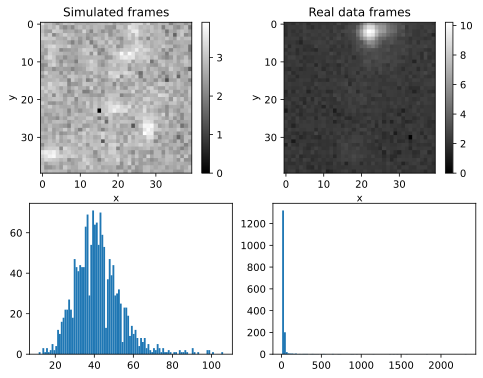

In [17]:

for i in range(20):
    sim_frame = sim_frames[torch.randint(0, len(sim_frames), size=(1, ))]

    random_iy = torch.randint(0, data_frames.shape[1]-sim_frame.shape[1], size=(1, ))
    random_ix = torch.randint(0, data_frames.shape[2]-sim_frame.shape[2], size=(1, ))
    data_frame = data_frames[torch.randint(0, len(data_frames), size=(1, )), random_iy:random_iy+sim_frame.shape[1], random_ix:random_ix+sim_frame.shape[2]]
    #data_frame = data_frames[torch.randint(0, len(data_frames), size=(1, )), 30:70,-40:]

    print(data_frame.shape, sim_frame.shape)
    plt.figure(figsize=(8,6))

    plt.subplot(221)
    decode.plot.PlotFrame(sim_frame).plot()
    plt.colorbar()
    plt.title('Simulated frames')

    plt.subplot(222)
    decode.plot.PlotFrame(data_frame).plot()
    plt.colorbar()
    plt.title('Real data frames')

    plt.subplot(223)
    sim_frame_np = sim_frame.cpu().numpy()
    plt.hist(sim_frame_np.flatten(), bins=100, label='Simulated Histogram')

    plt.subplot(224)
    data_frame_np = data_frame.cpu().numpy()
    plt.hist(data_frame_np.flatten(), bins=100, label='Real Data Histogram')

    #fname = rf'D:\Janelia_slm_data\figures\2025-06-12\simulation{i}.png'
    #plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

**Note:** If your available (i.e. free) GPU memory is lower than 6GB you will likely run into memory errors. Check your total GPU memory on the set device by running the cell below.
To avoid this you can lower the batch_size to 32 to 16. However you should have at least a 4GB GPU available. You might be able to run training on a smaller GPU using very small batch sizes but this will negatively impact performance.

**Note:** If other processes or a screen attached to the GPU you want to train on consumes GPU resources, the free GPU memory might be significantly lower than the total GPU memory size.

In [ ]:
if device != 'cpu':
    mem_gb = torch.cuda.get_device_properties(device).total_memory / 1e9
    print(f"Your approximate total GPU memory size on the set device {device} is {mem_gb:.2f} GB.")

param.HyperParameter.batch_size = 4 

Your approximate total GPU memory size on the set device cuda:0 is 8.33 GB.


Once you are happy with you settings you can write the parameters to a file (or edit the param_friendly.yaml directly)

In [20]:
model_dir = Path(r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25-calibration')
model_dir = Path(r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-ubuntu')

if not model_dir.exists():
    model_dir.mkdir(parents=True, exist_ok=True)
param_out_path = model_dir / 'params.yaml' # or an alternative path
decode.utils.param_io.save_params(param_out_path, param)

# Instruction to start the Actual Training of the Model from command line
To start training we recommend to start it from a new terminal window/Anaconda prompt as this is most stable. So please open up a new terminal, activate the respective environment and start the training.

    conda activate decode_env
    cd [directory where this notebook is]
    python -m decode.neuralfitter.train.live_engine -p notebook_example.yaml  # change path if you modified it

You can end training at any point by killing the associated process if you think that the model has converged. The current network is stored after every epoch.
You can also continue training (for example in case of crash) by setting the param.InOut.checkpoint_init parameter to the path of the ckpt.pt of the training run.

In case you experience multiprocessing issues, please consult our FAQ in our documentation (https://decode.readthedocs.io/). You may run the command above with the additional `-w 0` flag.

To check training progress you may start a tensorboard instance. Again, please open a new terminal instance and navigate (within the terminal, in a new terminal window/tab) to the directory of this notebook and start tensorboard. Don't forget to activate the conda environment before starting tensorboard.

    cd [directory which containts 'runs', i.e. this notebook's path]
    conda activate decode_env
    tensorboard --samples_per_plugin images=100 --port=6006 --logdir=runs

Open it in your browser: http://localhost:6006
Numereous evaluation metrics are tracked here. Under the 'Images' header you can see example frames and localizations.
Keep in mind though that these are all calculated on the simulated data. So you can check whether the training has converged,
but you'll have to run the model on the actual data to see if you set the parameters correctly.

For that open the Fit.ipynb notebook.

In [21]:
from decode.neuralfitter.train import live_engine
from decode.neuralfitter.utils import logger as logger_utils

device = 'cuda'

model_path = model_dir / 'decode_model.pt'
ckpt_path = model_dir / 'decode_ckpt.pt'


# set up tensorboard logger and dictionary logger
logger = [logger_utils.SummaryWriter(log_dir='logs',
                                     filter_keys=["dx_red_mu", "dx_red_sig",
                                                  "dy_red_mu", "dy_red_sig",
                                                  "dz_red_mu", "dz_red_sig",
                                                  "dphot_red_mu", "dphot_red_sig",
                                                  "f1",
                                                  ]),
          logger_utils.DictLogger()]
logger = logger_utils.MultiLogger(logger)

ds_train, ds_test, model, model_ls, optimizer, criterion, lr_scheduler, grad_mod, post_processor, matcher, ckpt = \
    live_engine.setup_trainer(simulator, sim_test, logger, model_path, ckpt_path, device, param)

dl_train, dl_test = live_engine.setup_dataloader(param, ds_train, ds_test)

# colab seems to have problems with pin_memory at the moment. So change this to False, although this can make training a bit slower
dl_train.pin_memory = False

epoch0 = 0

print("Training set up successfull.")

Model instantiated.
Model initialised as specified in the constructor.
Sampled dataset in 0.23s. 200425 emitters on 10001 frames.
Sampled dataset in 0.01s. 9735 emitters on 513 frames.
Training set up successfull.


/home/bnorthan/mambaforge/envs/decode_env/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [38]:
a,b,c = ds_test[100]
type(a), type(b), type(c), a.shape, len(b)
#a[0].shape, a[1].shape, a[2].shape, b.shape
type(ds_test), type(ds_train)

(decode.neuralfitter.dataset.SMLMAPrioriDataset,
 decode.neuralfitter.dataset.SMLMLiveDataset)

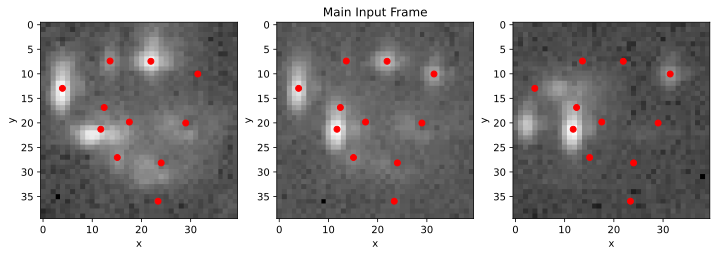

In [37]:
random_ix = torch.randint(len(ds_test), size=(1, )).item()

x_in, tar, weight = ds_test[random_ix]
tar_em = ds_test.emitter.get_subset_frame(random_ix, random_ix)

# input
plt.figure(figsize=(12, 8))
plt.subplot(131)
decode.plot.PlotFrameCoord(x_in[0], pos_tar=tar_em.xyz_px).plot()
plt.subplot(132)
decode.plot.PlotFrameCoord(x_in[1], pos_tar=tar_em.xyz_px).plot()
plt.title('Main Input Frame')
plt.subplot(133)
decode.plot.PlotFrameCoord(x_in[2], pos_tar=tar_em.xyz_px).plot()

In [22]:
ckpt = decode.utils.checkpoint.CheckPoint.load(ckpt_path)

model.load_state_dict(ckpt.model_state)
optimizer.load_state_dict(ckpt.optimizer_state)
lr_scheduler.load_state_dict(ckpt.lr_sched_state)
epoch0 = ckpt.step + 1

model = model.train()

In [23]:
%tensorboard --logdir logs

Launching TensorBoard...

In [24]:
converges = False
n = 0
n_max = param.HyperParameter.auto_restart_param.num_restarts

print(n_max,  param.HyperParameter.epochs, epoch0)


5 1000 2


In [25]:
max_epochs = 60
epoch0, n, n_max, max_epochs

(2, 0, 5, 60)

In [26]:
max_epochs =  1

max_epochs = max_epochs + epoch0
converges = False
n = 0
n_max = param.HyperParameter.auto_restart_param.num_restarts

while not converges and n < n_max:
  n += 1

  conv_check = decode.neuralfitter.utils.progress.GMMHeuristicCheck(
      ref_epoch=1,
      emitter_avg=simulator.em_sampler.em_avg,
      threshold=param.HyperParameter.auto_restart_param.restart_treshold,
  )

  for i in range(epoch0, max_epochs):#param.HyperParameter.epochs):
    logger.add_scalar('learning/learning_rate', optimizer.param_groups[0]['lr'], i)

    if i >= 1:
      train_loss = decode.neuralfitter.train_val_impl.train(
          model=model,
          optimizer=optimizer,
          loss=criterion,
          dataloader=dl_train,
          grad_rescale=param.HyperParameter.moeller_gradient_rescale,
          grad_mod=grad_mod,
          epoch=i,
          device=torch.device(param.Hardware.device),
          logger=logger
      )

    val_loss, test_out = decode.neuralfitter.train_val_impl.test(model=model, loss=criterion, dataloader=dl_test,
                                                                  epoch=i,
                                                                  device=torch.device(param.Hardware.device))

    if not conv_check(test_out.loss[:, 0].mean(), i):
      print(f"The model will be reinitialized and retrained due to a pathological loss. "
            f"The max. allowed loss per emitter is {conv_check.threshold:.1f} vs."
            f" {(test_out.loss[:, 0].mean() / conv_check.emitter_avg):.1f} (observed).")

      ds_train, ds_test, model, model_ls, optimizer, criterion, lr_scheduler, grad_mod, post_processor, matcher, ckpt = \
          decode.neuralfitter.train.live_engine.setup_trainer(simulator, sim_test, logger, model_path, ckpt_path, device, param)
      dl_train, dl_test = decode.neuralfitter.train.live_engine.setup_dataloader(param, ds_train, ds_test)

      converges = False
      break

    else:
      converges = True

    """Post-Process and Evaluate"""
    decode.neuralfitter.train.live_engine.log_train_val_progress.post_process_log_test(loss_cmp=test_out.loss, loss_scalar=val_loss,
                                                  x=test_out.x, y_out=test_out.y_out, y_tar=test_out.y_tar,
                                                  weight=test_out.weight, em_tar=ds_test.emitter,
                                                  px_border=-0.5, px_size=1.,
                                                  post_processor=post_processor, matcher=matcher, logger=logger,
                                                  step=i)

    if i >= 1:
        if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            lr_scheduler.step(val_loss)
        else:
            lr_scheduler.step()

    model_ls.save(model, None)
    ckpt.dump(model.state_dict(), optimizer.state_dict(), lr_scheduler.state_dict(),
                      log=logger.logger[1].log_dict, step=i)

    """Draw new samples Samples"""
    if param.Simulation.mode in 'acquisition':
        ds_train.sample(True)
    elif param.Simulation.mode != 'samples':
        raise ValueError

if converges:
    print("Training finished after reaching maximum number of epochs.")
else:
    raise ValueError(f"Training aborted after {n_max} restarts. "
                      "You can try to reduce the learning rate by a factor of 2."
                      "\nIt is also possible that the simulated data is to challenging. "
                      "Check if your background and intensity values are correct "
                      "and possibly lower the average number of emitters.")

  0%|          | 0/2499 [00:00<?, ?it/s]

(Test) E: 2 - T: 1.8: 100%|██████████| 128/128 [00:01<00:00, 70.32it/s]


Saved model to file: /home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-ubuntu/decode_model_0.pt
Sampled dataset in 0.22s. 200528 emitters on 10001 frames.
Training finished after reaching maximum number of epochs.


In [32]:
import numpy
numpy.__version__

'1.24.4'